Plot saved to 'theorem_2_1_demo.png'. Check the image to see the discrepancy.


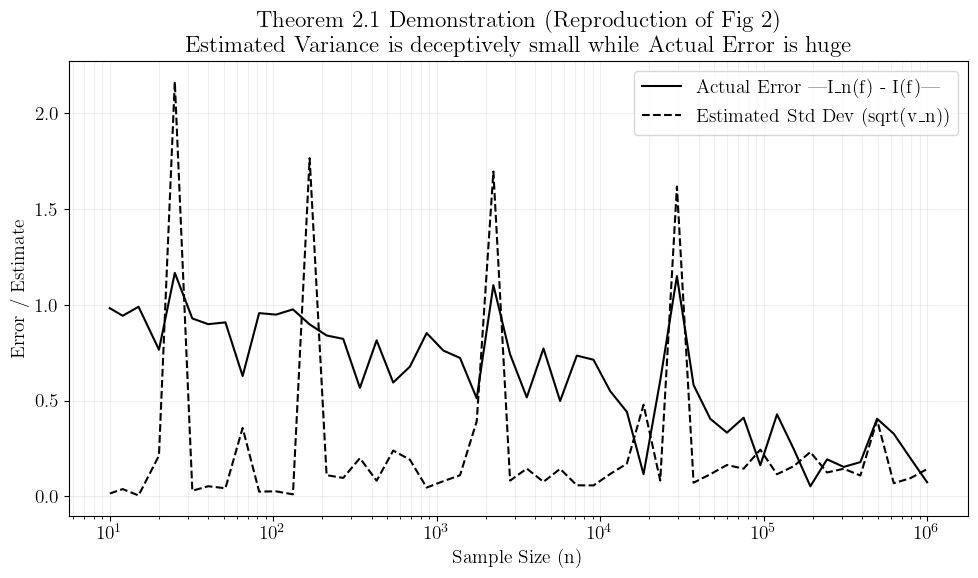

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

def run_importance_sampling_experiment():
    # --- 1. 设定参数 (对应论文 Example 2.2) ---
    N = 100
    p_mu = 0.5  # 采样分布 (Proposal) mu 的参数
    p_nu = 0.7  # 目标分布 (Target) nu 的参数
    
    # 目标函数 f(x) = 1。我们想估计 I(f) = E_nu[1] = 1。
    # 如果估计值远离 1，说明没收敛。
    true_value = 1.0 

    # --- 2. 模拟不同样本量下的表现 ---
    # 样本量从 10^1 到 10^6 (对应论文图2的横坐标范围)
    sample_sizes = np.logspace(1, 6, num=50, dtype=int)
    
    actual_errors = []
    estimated_stds = []

    # 为了平滑曲线，每个样本量我们重复实验几次取平均，或者单次运行
    # 这里为了演示波动性，我们只做单次运行，类似论文中的轨迹
    
    np.random.seed(42) # 固定随机种子以复现结果

    for n in sample_sizes:
        # A. 从分布 mu (Binomial(N, 0.5)) 中采样 n 个点
        X = np.random.binomial(N, p_mu, size=n)
        
        # B. 计算似然比权重 rho(x) = P_nu(x) / P_mu(x)
        # 使用 log 域计算避免溢出，然后 exp 回去
        # P(x|N,p) = C(N,x) * p^x * (1-p)^(N-x)
        # rho(x) = (p_nu/p_mu)^x * ((1-p_nu)/(1-p_mu))^(N-x)
        
        # 向量化计算权重
        log_rho = X * np.log(p_nu / p_mu) + (N - X) * np.log((1 - p_nu) / (1 - p_mu))
        rho = np.exp(log_rho)
        
        # C. 计算重要性采样估计值 I_n(f)
        # f(x) = 1, 所以 I_n = mean(rho)
        I_n = np.mean(rho)
        
        # D. 计算实际误差 (Actual Error)
        error = np.abs(I_n - true_value)
        actual_errors.append(error)
        
        # E. 计算经验方差估算量 v_n(f)
        # 根据论文公式 (1.2) 和 (2.3) 的经验版本:
        # v_n = (1/n^2) * sum( (f(Xi)*rho(Xi))^2 ) - (I_n^2 / n)
        # 因为 f(x)=1, 公式简化为:
        # v_n = (mean(rho^2) - mean(rho)^2) / n
        # 这就是权重的样本方差除以 n (标准误的平方)
        
        # 注意：这里直接用 np.var(rho) / n 即可，虽然论文公式写得展开了
        # np.var 默认是总体方差，ddof=1 是样本方差，但在 n 很大时差别忽略不计
        var_estimate = np.var(rho, ddof=1) / n
        std_estimate = np.sqrt(var_estimate)
        estimated_stds.append(std_estimate)

    # --- 3. 绘图结果 ---
    plt.figure(figsize=(10, 6))
    
    # 绘制实际误差
    plt.plot(sample_sizes, actual_errors, 'k-', label='Actual Error |I_n(f) - I(f)|', linewidth=1.5)
    
    # 绘制估计的标准差 (通常用作误差的诊断指标)
    plt.plot(sample_sizes, estimated_stds, 'k--', label='Estimated Std Dev (sqrt(v_n))', linewidth=1.5)
    
    plt.xscale('log')
    plt.xlabel('Sample Size (n)')
    plt.ylabel('Error / Estimate')
    plt.title('Theorem 2.1 Demonstration (Reproduction of Fig 2)\nEstimated Variance is deceptively small while Actual Error is huge')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    plt.tight_layout()
    plt.savefig('theorem_2_1_demo.png')
    print("Plot saved to 'theorem_2_1_demo.png'. Check the image to see the discrepancy.")

if __name__ == "__main__":
    run_importance_sampling_experiment()